In [1]:
import numpy as np
import xarray as xr
#import scipy as sci
import matplotlib.pyplot as plt # still need matplotlib
import xmitgcm
import xgcm 
import gsw

import cartopy.crs as ccrs
import cmocean
import matplotlib.ticker as mticker

## Final Decade Average Model Output

Making maps and zonal averages of changes. 

This should also include the supplementary figures. 

In [2]:
# Look at the final decade. 
myYr2 = np.arange(90,100)
myIts2 = 2880000 + 720*myYr2 # 720 timesteps in a year.
fol3 = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/run/'

# T and S output monthly, so times change
myYrTS = np.arange(90*720,100*720,60)
#print(myYr)
myItsTS = 2880000 + myYrTS

In [3]:

#fol3 = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/run/'
folGl = '/glade/derecho/scratch/bataylor/O2fix_23layer_YT/4Cstep_try1/'
GlTr = xmitgcm.open_mdsdataset(folGl, grid_dir = fol3, prefix = ['DICDiag3d'], iters = myIts2.tolist(), ignore_unknown_vars = True)
o2Gl  = xr.where(GlTr.TRAC05 ==0, np.nan, GlTr.TRAC05).mean('time')
ageGl = xr.where(GlTr.TRAC11 ==0, np.nan, GlTr.TRAC11).mean('time')

GlTS = xmitgcm.open_mdsdataset(folGl, grid_dir = fol3, prefix = ['Diag3d'], iters = myItsTS.tolist(), ignore_unknown_vars = True)
THGl = xr.where(GlTS.SALT ==0, np.nan, GlTS.THETA).mean('time')
SaGl = xr.where(GlTS.SALT ==0, np.nan, GlTS.SALT).mean('time')

In [4]:
folPacfade = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/saved_data/Pacfade_4C'
PacfTr = xmitgcm.open_mdsdataset(folPacfade, grid_dir = fol3, prefix = ['DICDiag3d'], iters = myIts2.tolist(), ignore_unknown_vars = True)

o2Pacf = xr.where(PacfTr.TRAC05 ==0, np.nan, PacfTr.TRAC05).mean('time')
agePacf= xr.where(PacfTr.TRAC11 ==0, np.nan, PacfTr.TRAC11).mean('time')

PacfTS = xmitgcm.open_mdsdataset(folPacfade, grid_dir = fol3, prefix = ['Diag3d'], iters = myItsTS.tolist(), ignore_unknown_vars = True)

THPacf = xr.where(PacfTS.SALT ==0, np.nan, PacfTS.THETA).mean('time')
SaPacf= xr.where(PacfTS.SALT ==0, np.nan, PacfTS.SALT).mean('time')

In [5]:

#fol3 = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/run/'
folSOfade = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/saved_data/SOfade_4C/'
SOfadeTr = xmitgcm.open_mdsdataset(folSOfade, grid_dir = fol3, prefix = ['DICDiag3d'], iters = myIts2.tolist(), ignore_unknown_vars = True)

o2SOfade = xr.where(SOfadeTr.TRAC05 ==0, np.nan, SOfadeTr.TRAC05).mean('time')
ageSOfade= xr.where(SOfadeTr.TRAC11 ==0, np.nan, SOfadeTr.TRAC11).mean('time')

SOTSf = xmitgcm.open_mdsdataset(folSOfade, grid_dir = fol3, prefix = ['Diag3d'], iters = myItsTS.tolist(), ignore_unknown_vars = True)
THSOfade = xr.where(SOTSf.SALT ==0, np.nan, SOTSf.THETA).mean('time')
SaSOfade = xr.where(SOTSf.SALT ==0, np.nan, SOTSf.SALT).mean('time')

In [6]:
#fol3 = '/glade/work/bataylor/checkpoint68r-MITgcm/ben_setups/layer23_ocn3deg/run/'
fol0 = '/glade/derecho/scratch/bataylor/O2fix_23layer_YT/Control_try1/'
CtlTr = xmitgcm.open_mdsdataset(fol0, grid_dir = fol3, prefix = ['DICDiag3d'], iters = myIts2.tolist(), ignore_unknown_vars = True)

o2con= xr.where(CtlTr.TRAC05 ==0, np.nan, CtlTr.TRAC05).mean('time')
agecon= xr.where(CtlTr.TRAC11 ==0, np.nan, CtlTr.TRAC11).mean('time')

CtlTS = xmitgcm.open_mdsdataset(fol0, grid_dir = fol3, prefix = ['Diag3d'], iters = myItsTS.tolist(), ignore_unknown_vars = True)

THcon= xr.where(CtlTS.SALT ==0, np.nan, CtlTS.THETA).mean('time')
Sacon= xr.where(CtlTS.SALT ==0, np.nan, CtlTS.SALT).mean('time')

/glade/u/apps/opt/conda/envs/npl-2024a/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/glade/u/apps/opt/conda/envs/npl-2024a/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/glade/u/apps/opt/conda/envs/npl-2024a/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/glade/u/apps/opt/conda/envs/npl-2024a/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/glade/u/apps/opt/conda/envs/npl-2024a/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/glade/u/apps/opt/conda/envs/n

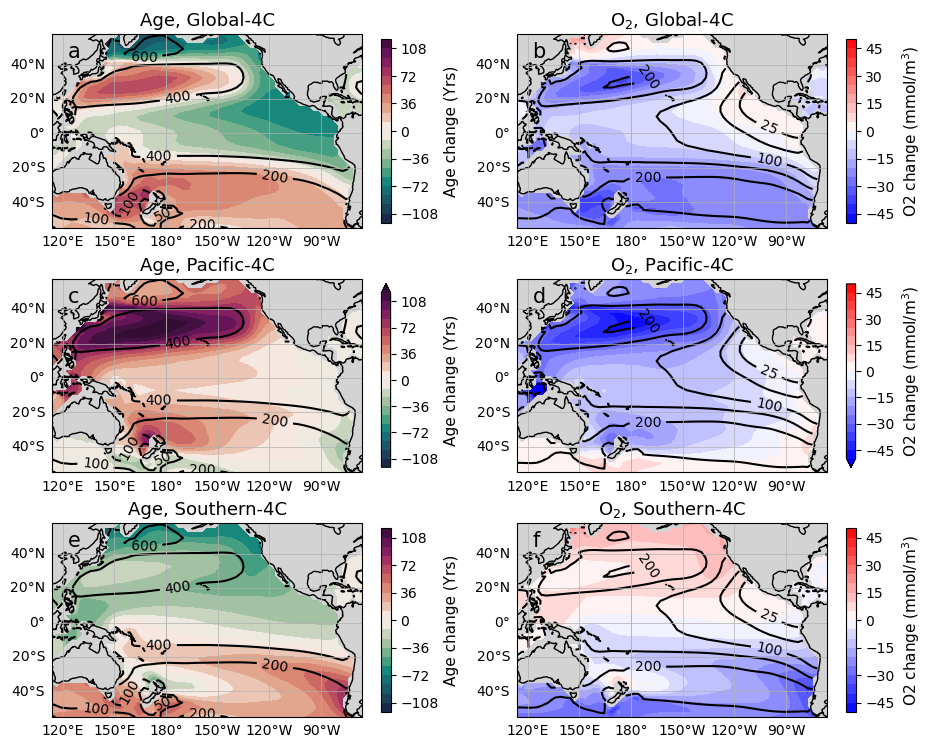

In [8]:
## Age and oxygen mapping (new figure 4). 
import cmocean
import matplotlib.ticker as mticker

#fig, axs = plt.subplots(ncols=2 , nrows = 2,figsize=(12,8))
xran = range(40,105)
yran = range(12,53)
zran = range(8,13)

SOTr = SOfadeTr
deps = SOfadeTr.drF.isel(Z=zran)*SOTr.hFacC.isel(XC = xran, YC = yran, Z= zran)
tmpSO = o2SOfade.isel( XC = xran, YC = yran, Z= zran)*SOTr.drF.isel(Z=zran) 
tmpPac = o2Pacf.isel( XC = xran, YC = yran, Z= zran)*SOTr.drF.isel(Z=zran) 
tmpGl = o2Gl.isel( XC = xran, YC = yran, Z= zran)*SOTr.drF.isel(Z=zran) 
#tmpNA = o2NA.isel( XC = xran, YC = yran, Z= zran)*SOTr.drF.isel(Z=zran) 
tmp0 = o2con.isel(XC = xran, YC = yran, Z= zran)*SOTr.drF.isel(Z=zran) 

PlSOo = tmpSO.sum('Z')/deps.sum('Z')
PlPaco = tmpPac.sum('Z')/deps.sum('Z')
PlGlo = tmpGl.sum('Z')/deps.sum('Z')
#PlNA = tmpNA.sum('Z')/deps.sum('Z')
Pl0o = tmp0.sum('Z')/deps.sum('Z')

vm = 50

o2levels = [0.025,0.05, 0.1, 0.15, .2, .25 ]
o2levels00 =[25, 50, 100, 150, 200, 250] 
#wlevels = [-3e-6, -0.5e-6,0,  0.5e-6, 3e-6]

proj = ccrs.PlateCarree(central_longitude=180)
fig, axs = plt.subplots(3, 2, figsize=(11, 9), subplot_kw={'projection': proj})
#axs = np.atleast_2d(axs)  # Ensure axs[0,0] indexing works if only one row


#vm = 120
#agelevels = [50, 100, 200, 400, 800, 1200, 1600 ]
#wlevels = [-3e-6, -0.5e-6,0,  0.5e-6, 3e-6]

Diag3d = PacfTr

cbarshr = 0.9
o2map = 'bwr'


# Contourf plot with Cartopy (left subplot)
A = axs[0,1].contourf(
    Diag3d.XC[xran],
    Diag3d.YC[yran],
    1000*(PlGlo - Pl0o),
    vmin=-vm,
    vmax=vm,
    levels=np.linspace(-vm, vm, 21),
    cmap=o2map,
    extend='neither',
    transform=ccrs.PlateCarree()
)

# Add colorbar
cbAo = plt.colorbar(A, ax=axs[0,1], orientation='vertical', pad=0.05, shrink=cbarshr)

cbAo.set_label('O2 change (mmol/m$^3$)', fontsize=11)

B = axs[1,1].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 1000*(PlPaco- Pl0o), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = o2map, extend='min', transform=ccrs.PlateCarree())
cbBo = plt.colorbar(B, ax= axs[1,1], pad=0.05, shrink=cbarshr)
cbBo.set_label('O2 change (mmol/m$^3$)', fontsize=11)


C = axs[2,1].contourf(Diag3d.XC[xran], Diag3d.YC[yran], 1000*(PlSOo- Pl0o), vmin = -vm, vmax = vm, 
                      levels = np.linspace(-vm, vm,21), cmap = o2map, transform=ccrs.PlateCarree())
cbCo = plt.colorbar(C, ax= axs[2,1], pad=0.05, shrink=cbarshr)
cbCo.set_label('O2 change (mmol/m$^3$)', fontsize=11)

lets = ['a','b','c','d','e','f']
j=1
for i in range(3):
    cl = axs[i,j].contour(Diag3d.XC[xran], Diag3d.YC[yran], 1000*Pl0o, colors= 'k', levels = o2levels00,transform=ccrs.PlateCarree())
    cl.clabel(levels = [25, 100, 200])
    axs[i,j].grid()
    axs[i,j].coastlines()
    gl = axs[i,j].gridlines(draw_labels=True, linewidth=0.5)
    gl.top_labels=False
    gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 30))
    axs[i,j].set_facecolor('lightgray')
    axs[i,j].text(0.05, 0.96, lets[2*i+j], fontsize=15, transform=axs[i,j].transAxes, ha='left', va='top')

        #axs[i,j].text(0.05, 0.9, letters[2*i+j], fontsize=14, transform=axs[i,j].transAxes, ha='left', va='top')
        

axs[0,1].set_title('O$_2$, Global-4C', fontsize=13)
axs[1,1].set_title('O$_2$, Pacific-4C', fontsize=13)
axs[2,1].set_title('O$_2$, Southern-4C', fontsize=13)
#axs[1,1].set_title('NAtlantic-4C', fontsize=14)

#proj = ccrs.PlateCarree(central_longitude=180)
#fig, axs = plt.subplots(2, 2, figsize=(11, 6), subplot_kw={'projection': proj})
#axs = np.atleast_2d(axs)  # Ensure axs[0,0] indexing works if only one row

agemap = cmocean.cm.curl
agemap.set_bad(color='black')
#agemap.set_bad(color='black')
#fig, axs = plt.subplots(ncols=2 , nrows = 2,figsize=(12,8))

vm = 120
agelevels = [50, 100, 200, 400, 600, 800, 1200, 1600 ]
#wlevels = [-3e-6, -0.5e-6,0,  0.5e-6, 3e-6]


cbarshr = 0.9

xran = range(40,105)
yran = range(12,53)
zran = range(8,13)

#PlSO = ageSO.isel( XC = xran, YC = yran, Z= zran).mean('Z')
deps = SOfadeTr.drF.isel(Z=zran)*SOTr.hFacC.isel(XC = xran, YC = yran, Z= zran)
tmpSO = ageSOfade.isel( XC = xran, YC = yran, Z= zran)*SOTr.drF.isel(Z=zran) 
tmpPac = agePacf.isel( XC = xran, YC = yran, Z= zran)*SOTr.drF.isel(Z=zran) 
tmpGl = ageGl.isel( XC = xran, YC = yran, Z= zran)*SOTr.drF.isel(Z=zran) 
#tmpNA = ageNA.isel( XC = xran, YC = yran, Z= zran)*SOTr.drF.isel(Z=zran) 
tmp0 = agecon.isel(XC = xran, YC = yran, Z= zran)*SOTr.drF.isel(Z=zran) 

PlSO = tmpSO.sum('Z')/deps.sum('Z')
PlPac = tmpPac.sum('Z')/deps.sum('Z')
PlGl = tmpGl.sum('Z')/deps.sum('Z')
#PlNAo = tmpNA.sum('Z')/deps.sum('Z')
Pl0 = tmp0.sum('Z')/deps.sum('Z')

# Contourf plot with Cartopy (left subplot)
A = axs[0,0].contourf(
    Diag3d.XC[xran],
    Diag3d.YC[yran],
    PlGl - Pl0,
    vmin=-vm,
    vmax=vm,
    levels=np.linspace(-vm, vm, 21),
    cmap=agemap,
    transform=ccrs.PlateCarree()
)

# Add colorbar
cbAa = plt.colorbar(A, ax=axs[0,0], orientation='vertical', pad=0.05, shrink=cbarshr)
cbAa.set_label('Age change (Yrs)', fontsize=11)
# Add additional contours
#axs[0,0].contour(
#    Diag3d.XC[xran],
#    Diag3d.YC[yran],
#    Pl0,
#    colors='k',
#    levels=agelevels,
#    transform=ccrs.PlateCarree()
#)


B = axs[1,0].contourf(Diag3d.XC[xran], Diag3d.YC[yran], PlPac- Pl0, vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = agemap, extend='max', transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
cbBa = plt.colorbar(B, ax= axs[1,0], pad=0.05, shrink=cbarshr)
cbBa.set_label('Age change (Yrs)', fontsize=11)

C = axs[2,0].contourf(Diag3d.XC[xran], Diag3d.YC[yran], PlSO- Pl0, vmin = -vm, vmax = vm, 
                      levels = np.linspace(-vm, vm,21), cmap = agemap, transform=ccrs.PlateCarree())
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
cbCa = plt.colorbar(C, ax= axs[2,0], pad=0.05, shrink=cbarshr)
cbCa.set_label('Age change (Yrs)', fontsize=11)

j=0
for i in range(3):
    cl = axs[i,j].contour(Diag3d.XC[xran], Diag3d.YC[yran], Pl0, colors= 'k', levels = agelevels,transform=ccrs.PlateCarree())
    cl.clabel()
    axs[i,j].grid()
    axs[i,j].coastlines()
    gl = axs[i,j].gridlines(draw_labels=True, linewidth=0.5)
    gl.top_labels=False
    gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 30))
    axs[i,j].set_facecolor('lightgray')
    axs[i,j].text(0.05, 0.96, lets[2*i+j], fontsize=15, transform=axs[i,j].transAxes, ha='left', va='top')

        #axs[i,j].text(0.05, 0.9, letters[2*i+j], fontsize=14, transform=axs[i,j].transAxes, ha='left', va='top')
        

axs[0,0].set_title('Age, Global-4C', fontsize=13)
axs[1,0].set_title('Age, Pacific-4C', fontsize=13)
axs[2,0].set_title('Age, Southern-4C', fontsize=13)
#axs[1,1].set_title('NAtlantic-4C', fontsize=14)

#plt.savefig('../eps_figures/Agemap8-14.eps')
#plt.show()



#plt.savefig('../eps_figures/AgeO2maps12-7.eps')

#plt.show()

In [10]:
## AOU calculations

# this is actually -1*AOU ...

aouSOf = o2SOfade - 0.001*gsw.O2sol(SaSOfade, THSOfade, -Diag3d.Z,  Diag3d.XC, Diag3d.YC)
aouPacf = o2Pacf - 0.001*gsw.O2sol(SaPacf, THPacf, -Diag3d.Z,  Diag3d.XC, Diag3d.YC)
aouGl = o2Gl - 0.001*gsw.O2sol(SaGl, THGl, -Diag3d.Z,  Diag3d.XC, Diag3d.YC)
aou0 = o2con - 0.001*gsw.O2sol(Sacon, THcon, -Diag3d.Z,  Diag3d.XC, Diag3d.YC)

#aouNA = o2NA - 0.001*gsw.O2sol(SaNA, THNA, -Diag3d.Z,  Diag3d.XC, Diag3d.YC)

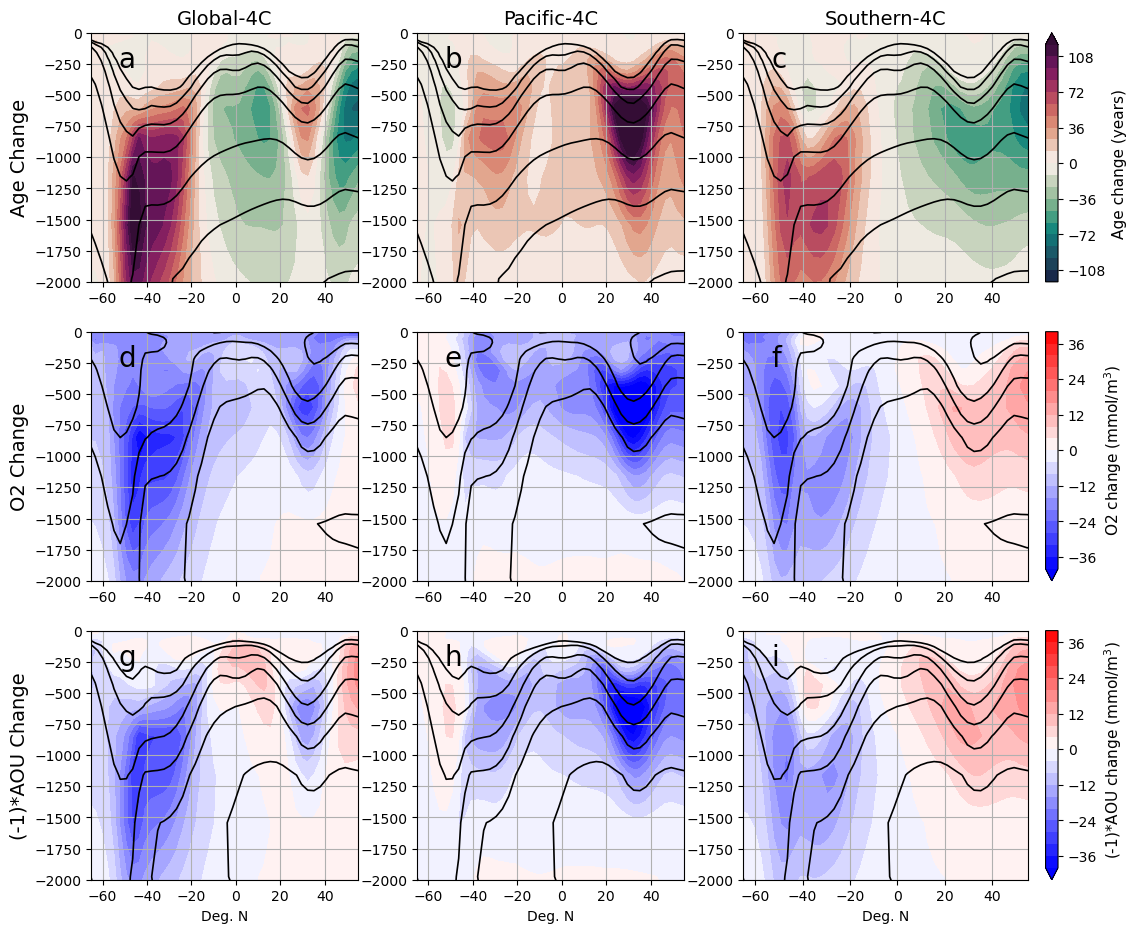

In [23]:
# 3x3 plots to show depth distribution of changes

# Jesus give me grace to focus and succeed here


widths = [0.3, 0.3, 0.4]
fig, axs = plt.subplots(ncols=3 , nrows = 3,figsize=(13,11), gridspec_kw={'width_ratios': widths})
xran = range(64,80)
yran = range(8,53)
zran = range(17)


PlSO = o2SOfade.isel( XC = xran, YC = yran, Z= zran).mean('XC')
PlPac = o2Pacf.isel( XC = xran, YC = yran, Z= zran).mean('XC')
PlGl = o2Gl.isel( XC = xran, YC = yran, Z= zran).mean('XC')

#PlNA = o2NA.isel( XC = xran, YC = yran, Z= zran).mean('XC')
Pl0 = o2con.isel(XC = xran, YC = yran, Z= zran).mean('XC')

#o2hzm = o2h.isel( XC = xran, YC = yran, Z= zran).mean('XC')
PlaSO = aouSOf.isel( XC = xran, YC = yran, Z= zran).mean('XC')
PlaPac = aouPacf.isel( XC = xran, YC = yran, Z= zran).mean('XC')
PlaGl = aouGl.isel( XC = xran, YC = yran, Z= zran).mean('XC')
#PlNA = aouNA.isel( XC = xran, YC = yran, Z= zran).mean('XC')
Pla0 = aou0.isel(XC = xran, YC = yran, Z= zran).mean('XC')
#yr = 50
vm = 40


PlageSO = ageSOfade.isel( XC = xran, YC = yran, Z= zran).mean('XC')
PlagePac = agePacf.isel( XC = xran, YC = yran, Z= zran).mean('XC')
PlageGl = ageGl.isel( XC = xran, YC = yran, Z= zran).mean('XC')
#PlNA = ageNA.isel( XC = xran, YC = yran, Z= zran).mean('XC')
Plage0 = agecon.isel(XC = xran, YC = yran, Z= zran).mean('XC')
#yr = 50
vma = 120


#vm2 = 0
agemap = cmocean.cm.curl
agelevels = [50, 100, 200, 400, 800, 1200, 1600 ]

Diag3d = SOTr
lw=1.2

A = axs[0,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], PlageGl-Plage0  , vmin = -vma, vmax = vma, extend='max', levels = np.linspace(-vma, vma, 21), cmap = agemap)
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
#plt.colorbar(A, ax= axs[0,0])
axs[0,0].set_ylim([-2000,0])
axs[0,0].contour(Diag3d.YC[yran], Diag3d.Z[zran], Plage0, colors= 'k', levels = agelevels, linewidths=lw)
axs[0,0].grid()

B = axs[0,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], PlagePac-Plage0, vmin = -vma, vmax = vma, extend = 'max',levels = np.linspace(-vma, vma,21), cmap = agemap)
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
#plt.colorbar(B, ax= axs[0,1])
axs[0,1].set_ylim([-2000,0])
axs[0,1].contour(Diag3d.YC[yran], Diag3d.Z[zran], Plage0, colors= 'k', levels = agelevels, linewidths=lw)
axs[0,1].grid()

M = axs[0,2].contourf(Diag3d.YC[yran], Diag3d.Z[zran], PlageSO-Plage0, vmin = -vma, vmax = vma, extend = 'max',levels = np.linspace(-vma,vma, 21), cmap = agemap)
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Mcb = plt.colorbar(M, ax= axs[0,2])
Mcb.set_label('Age change (years)', fontsize= 11)
axs[0,2].set_ylim([-2000,0])
axs[0,2].contour(Diag3d.YC[yran], Diag3d.Z[zran], Plage0, colors= 'k', levels = agelevels, linewidths=lw)
axs[0,2].grid()




o2levels = [0.025,0.05, 0.1, 0.15, .2, .25 ]

Diag3d = SOTr

A = axs[1,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*(PlGl - Pl0)  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr', extend = 'min')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
#plt.colorbar(A, ax= axs[1,0])
axs[1,0].set_ylim([-2000,0])
axs[1,0].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = o2levels, linewidths=lw)
axs[1,0].grid()

B = axs[1,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*(PlPac - Pl0), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr', extend = 'min')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
#plt.colorbar(B, ax= axs[1,1])
axs[1,1].set_ylim([-2000,0])
axs[1,1].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = o2levels, linewidths=lw)
axs[1,1].grid()

C = axs[1,2].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*(PlSO - Pl0), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr', extend = 'min')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
cbC = plt.colorbar(C, ax= axs[1,2])
cbC.set_label('O2 change (mmol/m$^3$)', fontsize=11)
axs[1,2].set_ylim([-2000,0])
axs[1,2].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0, colors= 'k', levels = o2levels, linewidths=lw)
axs[1,2].grid()

D = axs[2,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran],1000* (PlaGl- Pla0), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
#plt.colorbar(D, ax= axs[2,0])
axs[2,0].set_ylim([-2000,0])
axs[2,0].contour(Diag3d.YC[yran], Diag3d.Z[zran], -Pla0, colors= 'k', levels = o2levels, linewidths=lw)
axs[2,0].grid()

E = axs[2,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*(PlaPac-Pla0), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr', extend = 'min')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
#plt.colorbar(E, ax= axs[2,1])
axs[2,1].set_ylim([-2000,0])
axs[2,1].contour(Diag3d.YC[yran], Diag3d.Z[zran], -Pla0, colors= 'k', levels = o2levels, linewidths=lw)
axs[2,1].grid()

F = axs[2,2].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*(PlaSO-Pla0), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr',  extend = 'min')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
cbF = plt.colorbar(F, ax= axs[2,2])
cbF.set_label('(-1)*AOU change (mmol/m$^3$)', fontsize=11) 
axs[2,2].set_ylim([-2000,0])
axs[2,2].contour(Diag3d.YC[yran], Diag3d.Z[zran], -Pla0, colors= 'k', levels = o2levels, linewidths=lw)
axs[2,2].grid()

axs[0,0].set_title('Global-4C', fontsize = 14)
axs[0,1].set_title('Pacific-4C', fontsize = 14)
axs[0,2].set_title('Southern-4C', fontsize = 14)

axs[2,0].set_xlabel('Deg. N') 
axs[2,1].set_xlabel('Deg. N') 
axs[2,2].set_xlabel('Deg. N') 

axs[0,0].set_ylabel('Age Change', fontsize = 14)
axs[1,0].set_ylabel('O2 Change', fontsize=14)
axs[2,0].set_ylabel('(-1)*AOU Change', fontsize=14)

letters = ['a','b','c','d','e','f','g','h','i']
for i in range(3):
    for j in range(3):
        axs[i,j].text(0.1, 0.95, letters[3*i+j], fontsize=20, transform=axs[i,j].transAxes, ha='left', va='top')
        axs[i,j].set_xlim([-65,55])
#axs[3,1].text(0.1, 0.9, 'h', fontsize=20, transform=axs[3,1].transAxes, ha='left', va='top')

#axs[1,1].set_title('Pac 4Cstep + SO 4Cstep')


#plt.savefig('o2_aou_sections_7-9.eps')

#plt.savefig('../eps_figures/age_o2_aou_sections11-14.eps')
#plt.show()


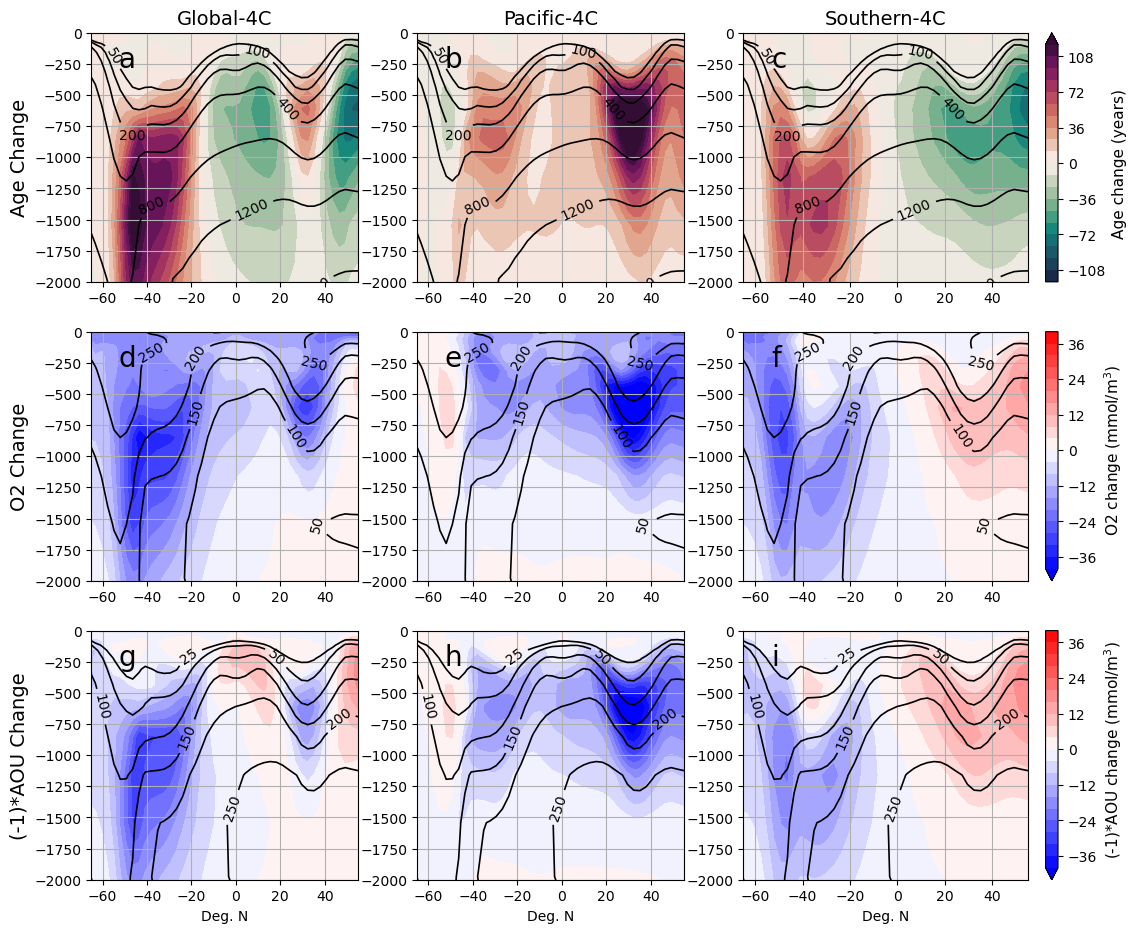

In [14]:
# 3x3 plots to show depth distribution of changes

# OK just adding the labels to the contours! 


widths = [0.3, 0.3, 0.4]
fig, axs = plt.subplots(ncols=3 , nrows = 3,figsize=(13,11), gridspec_kw={'width_ratios': widths})
xran = range(64,80)
yran = range(8,53)
zran = range(17)


PlSO = o2SOfade.isel( XC = xran, YC = yran, Z= zran).mean('XC')
PlPac = o2Pacf.isel( XC = xran, YC = yran, Z= zran).mean('XC')
PlGl = o2Gl.isel( XC = xran, YC = yran, Z= zran).mean('XC')

#PlNA = o2NA.isel( XC = xran, YC = yran, Z= zran).mean('XC')
Pl0 = o2con.isel(XC = xran, YC = yran, Z= zran).mean('XC')

#o2hzm = o2h.isel( XC = xran, YC = yran, Z= zran).mean('XC')
PlaSO = aouSOf.isel( XC = xran, YC = yran, Z= zran).mean('XC')
PlaPac = aouPacf.isel( XC = xran, YC = yran, Z= zran).mean('XC')
PlaGl = aouGl.isel( XC = xran, YC = yran, Z= zran).mean('XC')
#PlNA = aouNA.isel( XC = xran, YC = yran, Z= zran).mean('XC')
Pla0 = aou0.isel(XC = xran, YC = yran, Z= zran).mean('XC')
#yr = 50
vm = 40


PlageSO = ageSOfade.isel( XC = xran, YC = yran, Z= zran).mean('XC')
PlagePac = agePacf.isel( XC = xran, YC = yran, Z= zran).mean('XC')
PlageGl = ageGl.isel( XC = xran, YC = yran, Z= zran).mean('XC')
#PlNA = ageNA.isel( XC = xran, YC = yran, Z= zran).mean('XC')
Plage0 = agecon.isel(XC = xran, YC = yran, Z= zran).mean('XC')
#yr = 50
vma = 120


#vm2 = 0
agemap = cmocean.cm.curl
agelevels = [50, 100, 200, 400, 800, 1200, 1600]

Diag3d = SOTr
lw=1.2

A = axs[0,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], PlageGl-Plage0  , vmin = -vma, vmax = vma, extend='max', levels = np.linspace(-vma, vma, 21), cmap = agemap)
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
#plt.colorbar(A, ax= axs[0,0])
axs[0,0].set_ylim([-2000,0])
cl0 = axs[0,0].contour(Diag3d.YC[yran], Diag3d.Z[zran], Plage0, colors= 'k', levels = agelevels, linewidths=lw)
cl0.clabel()
axs[0,0].grid()

B = axs[0,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], PlagePac-Plage0, vmin = -vma, vmax = vma, extend = 'max',levels = np.linspace(-vma, vma,21), cmap = agemap)
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
#plt.colorbar(B, ax= axs[0,1])
axs[0,1].set_ylim([-2000,0])
cl1 = axs[0,1].contour(Diag3d.YC[yran], Diag3d.Z[zran], Plage0, colors= 'k', levels = agelevels, linewidths=lw)
cl1.clabel()
axs[0,1].grid()

M = axs[0,2].contourf(Diag3d.YC[yran], Diag3d.Z[zran], PlageSO-Plage0, vmin = -vma, vmax = vma, extend = 'max',levels = np.linspace(-vma,vma, 21), cmap = agemap)
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Mcb = plt.colorbar(M, ax= axs[0,2])
Mcb.set_label('Age change (years)', fontsize= 11)
axs[0,2].set_ylim([-2000,0])
cl2 = axs[0,2].contour(Diag3d.YC[yran], Diag3d.Z[zran], Plage0, colors= 'k', levels = agelevels, linewidths=lw)
cl2.clabel()
axs[0,2].grid()




o2levels = [0.025,0.05, 0.1, 0.15, .2, .25 ]
o2levels = [1000*k for k in o2levels]
#[element * 1000 for element in original_list]

Diag3d = SOTr

A = axs[1,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*(PlGl - Pl0)  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr', extend = 'min')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
#plt.colorbar(A, ax= axs[1,0])
axs[1,0].set_ylim([-2000,0])
cl3 = axs[1,0].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0*1000, colors= 'k', levels = o2levels, linewidths=lw)
cl3.clabel()
axs[1,0].grid()

B = axs[1,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*(PlPac - Pl0), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr', extend = 'min')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
#plt.colorbar(B, ax= axs[1,1])
axs[1,1].set_ylim([-2000,0])
cl4 = axs[1,1].contour(Diag3d.YC[yran], Diag3d.Z[zran], 1000*Pl0, colors= 'k', levels = o2levels, linewidths=lw)
cl4.clabel()
axs[1,1].grid()

C = axs[1,2].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*(PlSO - Pl0), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr', extend = 'min')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
cbC = plt.colorbar(C, ax= axs[1,2])
cbC.set_label('O2 change (mmol/m$^3$)', fontsize=11)
axs[1,2].set_ylim([-2000,0])
cl5 = axs[1,2].contour(Diag3d.YC[yran], Diag3d.Z[zran], 1000*Pl0, colors= 'k', levels = o2levels, linewidths=lw)
cl5.clabel() 
axs[1,2].grid()

D = axs[2,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran],1000* (PlaGl- Pla0), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
#plt.colorbar(D, ax= axs[2,0])
axs[2,0].set_ylim([-2000,0])
cl6 = axs[2,0].contour(Diag3d.YC[yran], Diag3d.Z[zran], -1000*Pla0, colors= 'k', levels = o2levels, linewidths=lw)
cl6.clabel()
axs[2,0].grid()

E = axs[2,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*(PlaPac-Pla0), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr', extend = 'min')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
#plt.colorbar(E, ax= axs[2,1])
axs[2,1].set_ylim([-2000,0])
cl7 = axs[2,1].contour(Diag3d.YC[yran], Diag3d.Z[zran], -1000*Pla0, colors= 'k', levels = o2levels, linewidths=lw)
cl7.clabel()
axs[2,1].grid()

F = axs[2,2].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*(PlaSO-Pla0), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr',  extend = 'min')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
cbF = plt.colorbar(F, ax= axs[2,2])
cbF.set_label('(-1)*AOU change (mmol/m$^3$)', fontsize=11) 
axs[2,2].set_ylim([-2000,0])
cl8 = axs[2,2].contour(Diag3d.YC[yran], Diag3d.Z[zran], -1000*Pla0, colors= 'k', levels = o2levels, linewidths=lw)
cl8.clabel() 
axs[2,2].grid()

axs[0,0].set_title('Global-4C', fontsize = 14)
axs[0,1].set_title('Pacific-4C', fontsize = 14)
axs[0,2].set_title('Southern-4C', fontsize = 14)

axs[2,0].set_xlabel('Deg. N') 
axs[2,1].set_xlabel('Deg. N') 
axs[2,2].set_xlabel('Deg. N') 

axs[0,0].set_ylabel('Age Change', fontsize = 14)
axs[1,0].set_ylabel('O2 Change', fontsize=14)
axs[2,0].set_ylabel('(-1)*AOU Change', fontsize=14)

letters = ['a','b','c','d','e','f','g','h','i']
for i in range(3):
    for j in range(3):
        axs[i,j].text(0.1, 0.95, letters[3*i+j], fontsize=20, transform=axs[i,j].transAxes, ha='left', va='top')
        axs[i,j].set_xlim([-65,55])
#axs[3,1].text(0.1, 0.9, 'h', fontsize=20, transform=axs[3,1].transAxes, ha='left', va='top')

#axs[1,1].set_title('Pac 4Cstep + SO 4Cstep')


#plt.savefig('o2_aou_sections_7-9.eps')

#plt.savefig('../eps_figures/age_o2_aou_sections12-7.eps', bbox_inches="tight")
#plt.show()


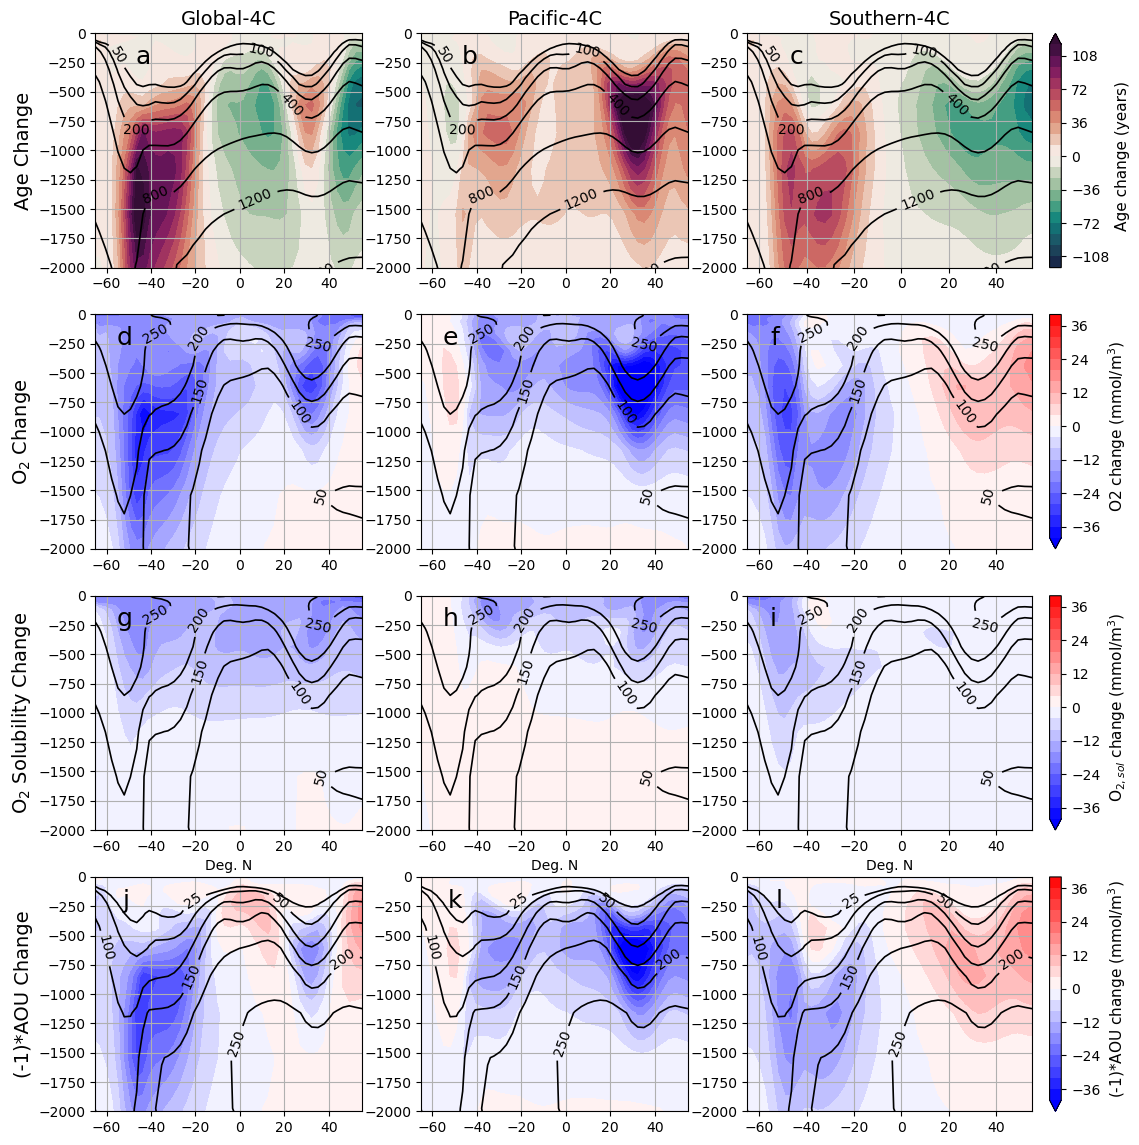

In [18]:
# 3x4 plots to show depth distribution of changes 
# now including solubility as well!! 

# OK just adding the labels to the contours! 


widths = [0.3, 0.3, 0.4]
fig, axs = plt.subplots(ncols=3 , nrows = 4,figsize=(13,14), gridspec_kw={'width_ratios': widths})
xran = range(64,80)
yran = range(8,53)
zran = range(17)


PlSO = o2SOfade.isel( XC = xran, YC = yran, Z= zran).mean('XC')
PlPac = o2Pacf.isel( XC = xran, YC = yran, Z= zran).mean('XC')
PlGl = o2Gl.isel( XC = xran, YC = yran, Z= zran).mean('XC')

#PlNA = o2NA.isel( XC = xran, YC = yran, Z= zran).mean('XC')
Pl0 = o2con.isel(XC = xran, YC = yran, Z= zran).mean('XC')

#o2hzm = o2h.isel( XC = xran, YC = yran, Z= zran).mean('XC')
PlaSO = aouSOf.isel( XC = xran, YC = yran, Z= zran).mean('XC')
PlaPac = aouPacf.isel( XC = xran, YC = yran, Z= zran).mean('XC')
PlaGl = aouGl.isel( XC = xran, YC = yran, Z= zran).mean('XC')
#PlNA = aouNA.isel( XC = xran, YC = yran, Z= zran).mean('XC')
Pla0 = aou0.isel(XC = xran, YC = yran, Z= zran).mean('XC')
#yr = 50
vm = 40


PlageSO = ageSOfade.isel( XC = xran, YC = yran, Z= zran).mean('XC')
PlagePac = agePacf.isel( XC = xran, YC = yran, Z= zran).mean('XC')
PlageGl = ageGl.isel( XC = xran, YC = yran, Z= zran).mean('XC')
#PlNA = ageNA.isel( XC = xran, YC = yran, Z= zran).mean('XC')
Plage0 = agecon.isel(XC = xran, YC = yran, Z= zran).mean('XC')
#yr = 50
vma = 120


#vm2 = 0
agemap = cmocean.cm.curl
agelevels = [50, 100, 200, 400, 800, 1200, 1600]

Diag3d = SOTr
lw=1.2

A = axs[0,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], PlageGl-Plage0  , vmin = -vma, vmax = vma, extend='max', levels = np.linspace(-vma, vma, 21), cmap = agemap)
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
#plt.colorbar(A, ax= axs[0,0])
axs[0,0].set_ylim([-2000,0])
cl0 = axs[0,0].contour(Diag3d.YC[yran], Diag3d.Z[zran], Plage0, colors= 'k', levels = agelevels, linewidths=lw)
cl0.clabel()
axs[0,0].grid()

B = axs[0,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], PlagePac-Plage0, vmin = -vma, vmax = vma, extend = 'max',levels = np.linspace(-vma, vma,21), cmap = agemap)
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
#plt.colorbar(B, ax= axs[0,1])
axs[0,1].set_ylim([-2000,0])
cl1 = axs[0,1].contour(Diag3d.YC[yran], Diag3d.Z[zran], Plage0, colors= 'k', levels = agelevels, linewidths=lw)
cl1.clabel()
axs[0,1].grid()

M = axs[0,2].contourf(Diag3d.YC[yran], Diag3d.Z[zran], PlageSO-Plage0, vmin = -vma, vmax = vma, extend = 'max',levels = np.linspace(-vma,vma, 21), cmap = agemap)
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
Mcb = plt.colorbar(M, ax= axs[0,2])
Mcb.set_label('Age change (years)', fontsize= 11)
axs[0,2].set_ylim([-2000,0])
cl2 = axs[0,2].contour(Diag3d.YC[yran], Diag3d.Z[zran], Plage0, colors= 'k', levels = agelevels, linewidths=lw)
cl2.clabel()
axs[0,2].grid()




o2levels = [0.025,0.05, 0.1, 0.15, .2, .25 ]
o2levels = [1000*k for k in o2levels]
#[element * 1000 for element in original_list]

Diag3d = SOTr

A = axs[1,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*(PlGl - Pl0)  , vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr', extend = 'min')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
#plt.colorbar(A, ax= axs[1,0])
axs[1,0].set_ylim([-2000,0])
cl3 = axs[1,0].contour(Diag3d.YC[yran], Diag3d.Z[zran], Pl0*1000, colors= 'k', levels = o2levels, linewidths=lw)
cl3.clabel()
axs[1,0].grid()

B = axs[1,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*(PlPac - Pl0), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr', extend = 'min')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
#plt.colorbar(B, ax= axs[1,1])
axs[1,1].set_ylim([-2000,0])
cl4 = axs[1,1].contour(Diag3d.YC[yran], Diag3d.Z[zran], 1000*Pl0, colors= 'k', levels = o2levels, linewidths=lw)
cl4.clabel()
axs[1,1].grid()

C = axs[1,2].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*(PlSO - Pl0), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr', extend = 'min')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
cbC = plt.colorbar(C, ax= axs[1,2])
cbC.set_label('O2 change (mmol/m$^3$)', fontsize=11)
axs[1,2].set_ylim([-2000,0])
cl5 = axs[1,2].contour(Diag3d.YC[yran], Diag3d.Z[zran], 1000*Pl0, colors= 'k', levels = o2levels, linewidths=lw)
cl5.clabel() 
axs[1,2].grid()

## solubility here! 

D = axs[2,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran],1000* (PlGl - Pl0 - PlaGl+ Pla0), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
#plt.colorbar(D, ax= axs[2,0])
axs[2,0].set_ylim([-2000,0])
cl6 = axs[2,0].contour(Diag3d.YC[yran], Diag3d.Z[zran], 1000*Pl0, colors= 'k', levels = o2levels, linewidths=lw)
cl6.clabel()
axs[2,0].grid()

E = axs[2,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*(PlPac - Pl0 - PlaPac+ Pla0), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr', extend = 'min')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
#plt.colorbar(E, ax= axs[2,1])
axs[2,1].set_ylim([-2000,0])
cl7 = axs[2,1].contour(Diag3d.YC[yran], Diag3d.Z[zran], 1000*Pl0, colors= 'k', levels = o2levels, linewidths=lw)
cl7.clabel()
axs[2,1].grid()

F = axs[2,2].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*(PlSO - Pl0 - PlaSO+Pla0), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr',  extend = 'min')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
cbF = plt.colorbar(F, ax= axs[2,2])
cbF.set_label('O$_{2,sol}$ change (mmol/m$^3$)', fontsize=11) 
axs[2,2].set_ylim([-2000,0])
cl8 = axs[2,2].contour(Diag3d.YC[yran], Diag3d.Z[zran], 1000*Pl0, colors= 'k', levels = o2levels, linewidths=lw)
cl8.clabel() 
axs[2,2].grid()

## AOU here

D = axs[3,0].contourf(Diag3d.YC[yran], Diag3d.Z[zran],1000* (PlaGl- Pla0), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
#plt.colorbar(D, ax= axs[2,0])
axs[3,0].set_ylim([-2000,0])
cl6 = axs[3,0].contour(Diag3d.YC[yran], Diag3d.Z[zran], -1000*Pla0, colors= 'k', levels = o2levels, linewidths=lw)
cl6.clabel()
axs[3,0].grid()

E = axs[3,1].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*(PlaPac-Pla0), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr', extend = 'min')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
#plt.colorbar(E, ax= axs[2,1])
axs[3,1].set_ylim([-2000,0])
cl7 = axs[3,1].contour(Diag3d.YC[yran], Diag3d.Z[zran], -1000*Pla0, colors= 'k', levels = o2levels, linewidths=lw)
cl7.clabel()
axs[3,1].grid()

F = axs[3,2].contourf(Diag3d.YC[yran], Diag3d.Z[zran], 1000*(PlaSO-Pla0), vmin = -vm, vmax = vm, levels = np.linspace(-vm, vm,21), cmap = 'bwr',  extend = 'min')
#plt.contour(Diag3d.YC[15:48], Diag3d.Z[0:10], sigzm.isel(time=5), colors= 'g', levels = [23,24,25,26,27,27.5,28,28.3,28.6, 29,29.2])
#plt.contourf(Diag3d.YC[15:48], Diag3d.Z[0:10], o2zm.isel(time=10) - o2zm.isel(time=0),)
cbF = plt.colorbar(F, ax= axs[3,2])
cbF.set_label('(-1)*AOU change (mmol/m$^3$)', fontsize=11) 
axs[3,2].set_ylim([-2000,0])
cl8 = axs[3,2].contour(Diag3d.YC[yran], Diag3d.Z[zran], -1000*Pla0, colors= 'k', levels = o2levels, linewidths=lw)
cl8.clabel() 
axs[3,2].grid()

axs[0,0].set_title('Global-4C', fontsize = 14)
axs[0,1].set_title('Pacific-4C', fontsize = 14)
axs[0,2].set_title('Southern-4C', fontsize = 14)

axs[2,0].set_xlabel('Deg. N') 
axs[2,1].set_xlabel('Deg. N') 
axs[2,2].set_xlabel('Deg. N') 

axs[0,0].set_ylabel('Age Change', fontsize = 14)
axs[1,0].set_ylabel('O$_2$ Change', fontsize=14)
axs[2,0].set_ylabel('O$_2$ Solubility Change', fontsize=14)
axs[3,0].set_ylabel('(-1)*AOU Change', fontsize=14)

letters = ['a','b','c','d','e','f','g','h','i', 'j', 'k', 'l']
x_loc = [0.15,0.08,0.08,0.1] # where to place the labels. 
for i in range(4):
    for j in range(3):
        axs[i,j].text(x_loc[i], 0.95, letters[3*i+j], fontsize=18, transform=axs[i,j].transAxes, ha='left', va='top')
        axs[i,j].set_xlim([-65,55])
#axs[3,1].text(0.1, 0.9, 'h', fontsize=20, transform=axs[3,1].transAxes, ha='left', va='top')

#axs[1,1].set_title('Pac 4Cstep + SO 4Cstep')


#plt.savefig('o2_aou_sections_7-9.eps')

plt.savefig('../eps_figures/age_o2_aou_sections12-22.eps', bbox_inches="tight")
#plt.show()
